In [4]:
import numpy as np
import scipy.constants as sc
import matplotlib.pyplot as plt
from pygmid import Lookup as lk
pmos4 = lk('../lookup_table/035/pmos4.mat')
nmos4 = lk('../lookup_table/035/nmos4.mat')
import sys; sys.path.append('../')
import adri

## 5T OTA  
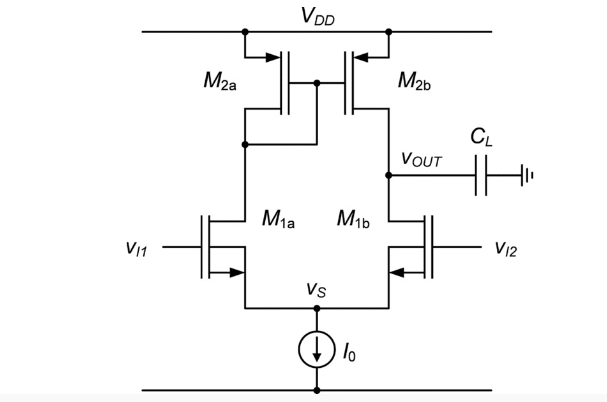
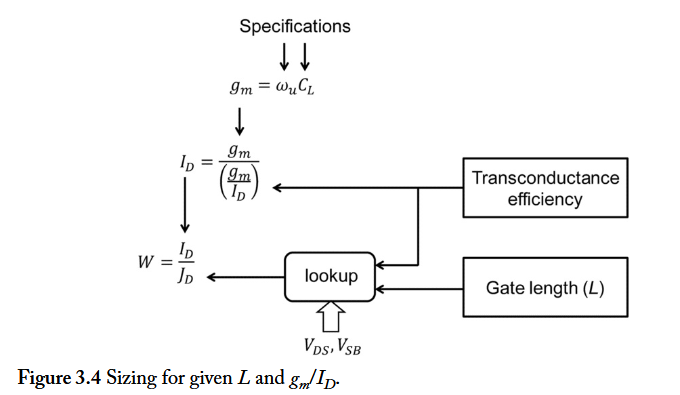

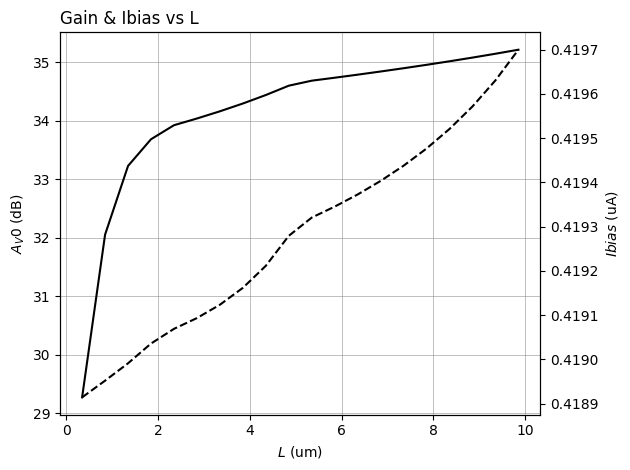

In [5]:
#Short version + exemple sweep L pour voir gain et ibias
AV_test = []
IBIAS_test = []
for l_test in np.arange(0.35, 10, 0.5):
    spec = {'fu' : 100e3, 'cload' : 10e-12,'vdd' : 2.7,'vic' : 1.35}
    param = {'l_mos' : l_test, 'gm_id1' : 15, 'gm_id2' : 10}
    mos,mos2,perf = adri.ota_5T_L_gmid(nmos4, pmos4, spec, param)
    AV_test.append(perf['AV0'])
    IBIAS_test.append(perf['ibias']*1e6)

l_test = np.arange(0.35, 10, 0.5)
AV_test_dB = 20*np.log10(AV_test)

fig, ax1 = plt.subplots()
ax1.grid(True, which='both', linestyle='-', linewidth=0.5, color='gray', alpha=0.7)
ax1.plot(l_test, AV_test_dB, color='black', linewidth=1.5)
plt.xlabel('$L$ (um)')
plt.ylabel(r'$A_V0$ (dB)')
ax2 = ax1.twinx()
ax2.plot(l_test, IBIAS_test,linestyle='--', color='black', linewidth=1.5)
plt.ylabel(r'$Ibias$ (uA)')
#ax2.ticklabel_format(axis='y', style='sci', scilimits=(-4, -4), useMathText=True)

ax2.set_title('Gain & Ibias vs L', loc='left', fontsize=12, fontweight='normal')
plt.tight_layout()
plt.show()


In [6]:
#Specification
FU = 10e6
CL = 10e-12
VDD = 2.7
V_IC = 1.35

In [7]:
#Hypothèse : L et GM
L12 = 2
gmID1 = 15
gmID2 = 10


In [8]:
#gm and ID, from Spec and Hypothesis
gm1 = 2*3.14159*FU*CL
ID = gm1 / gmID1
#VGS from lookupVGS, L and GM_ID
# Find VDS1 and 
VGS1 = nmos4.lookupVGS(GM_ID=gmID1, L=L12, VDS=0.6, VSB=0) #Fist estimation with vds default
VGS2 = pmos4.lookupVGS(GM_ID=gmID2, L=L12, VDS=0.6, VSB=0) #Fist estimation with vds default
VGS2 = pmos4.lookupVGS(GM_ID=gmID2, L=L12, VDS=VGS2, VSB=0) #Second with VDS = VGS (current mirror)
VD = VDD - VGS2
VS = V_IC - VGS1
VDS1 = VD - VS
VGS1 = nmos4.lookupVGS(GM_ID=gmID1, L=L12, VDS=VDS1, VSB=0) #Second with VDS more accurate
VDS2 = VGS2
##Design terminé##

#Calcul Gain
gdsID1 = nmos4.look_up('GDS_ID', GM_ID=gmID1, VDS=VDS1, L=L12, VSB=0)
gdsID2 = pmos4.look_up('GDS_ID', GM_ID=gmID2, VDS=VDS2, L=L12, VSB=0)
AV0 = gmID1 / (gdsID1 + gdsID2)

print('AV0 = %.2F' % AV0)
print('gm1 = %.2F uS' % (gm1 * 1e6))
print('ID = %.2F uA before self loading' % (ID*1e6))

CselfLoading = 0
for m in range(1,10,1):
    #self loading
    gm1 = 2*3.14159*FU*(CL+CselfLoading)
    ID = gm1 / gmID1
    #Denormalization
    JD1 = nmos4.lookup('ID_W', GM_ID=gmID1, VDS=VDS1, L=L12, VSB=0)
    JD2 = pmos4.lookup('ID_W', GM_ID=gmID2, VDS=VGS2, L=L12, VSB=0)
    W1 = ID/JD1
    W2 = ID/JD2
    #print('ID = %.2F uA' % (ID* 1e6))
    #print('W1 = %.2F um' % (W1))
    #print('W2 = %.2F um' % (W2))
    CDD1 = W1 * nmos4.look_up('CDD_W', GM_ID=gmID1, L=L12, VSB=0)
    CDD2 = W2 * pmos4.look_up('CDD_W', GM_ID=gmID2, L=L12, VSB=0)
    CselfLoading = CDD1 + CDD2
print('ID = %.2F uA before self loading' % (ID*1e6))


AV0 = 290.37
gm1 = 628.32 uS
ID = 41.89 uA before self loading
ID = 43.72 uA before self loading


In [9]:
print('AV0 = %.2F dB' % (20*np.log10(AV0)))
print('gm1 = %.2F uS' % (gm1 * 1e6))    
print('ID = %.2F uA' % (ID* 1e6))
print('W1 = %.2F um' % (W1))
print('W2 = %.2F um' % (W2))

AV0 = 49.26 dB
gm1 = 655.85 uS
ID = 43.72 uA
W1 = 104.47 um
W2 = 102.57 um


Essayre de plot un truc comme ça   
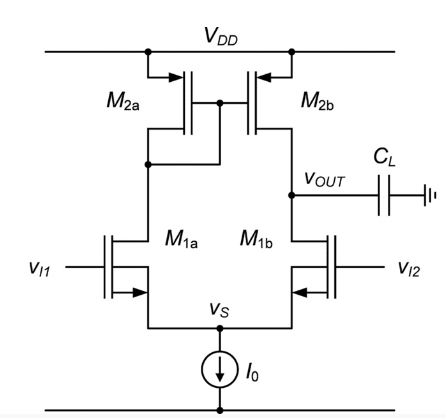
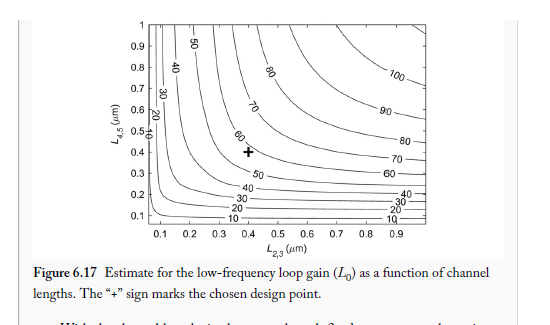

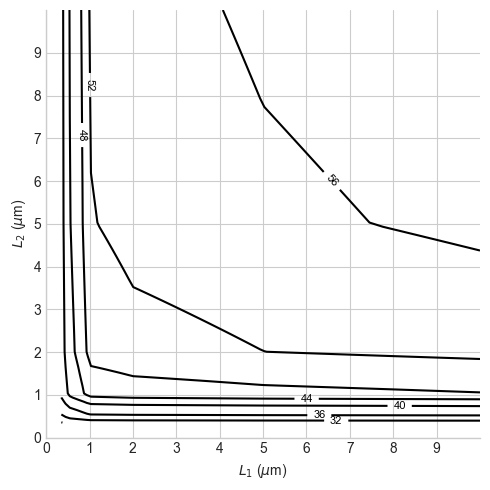

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pygmid import Lookup as lk
from format_and_save import format_and_save
from scipy.interpolate import interp1d
# setup matplotlib
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams.update({"axes.grid": True})
# Interpolation function
def interp1(x, y, value):
    # Perform cubic interpolation using interp1d
    f = interp1d(x, y, kind='cubic')
    return f(value)

Lsweep = np.linspace(0.35, 10, 100)
gmID1 = 15
gmID2 = gmID1
gdsID1 = nmos4.look_up('GDS_ID', GM_ID=gmID1, VDS=VDD/2, L=Lsweep, VSB=0)
gdsID2 = pmos4.look_up('GDS_ID', GM_ID=gmID2, VDS=VDD/2, L=Lsweep, VSB=0)
L0 = np.zeros((len(Lsweep), len(Lsweep)))

for j in range(len(Lsweep)):
    L0[j,:] = gmID1 / (gdsID1 + gdsID2[j])

L0 = 20*np.log10(L0)
plt.style.use("seaborn-v0_8-whitegrid")
# Plotting
fig, ax = plt.subplots(figsize=(5,5))
C = ax.contour(Lsweep, Lsweep, L0, colors='k', levels = 8 )
ax.clabel(C, fmt='%d', fontsize=8)
ax.set_xticks(np.arange(0, 10, 1))
ax.set_yticks(np.arange(0, 10, 1))
ax.set_xlabel(r'$L_{1}$ ($\mu$m)')
ax.set_ylabel(r'$L_{2}$ ($\mu$m)')
#ax.plot(0.35, 0.35, 'k+', markersize=9, linewidth=2)

plt.tight_layout()
plt.show()